FACTORS SET TO 20, LOOKING FOR FACTORS EQUIVALENT TO THOSE IN THE PAPER. COMPARE GENE RELEVANCE AFTER THIS. 

In [1]:
import numpy as np 
import pandas as pd 

In [2]:
barcodes = pd.read_csv("/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed_filtered_hsc/barcodes.csv")

true_barcodes = [open('/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed_filtered_hsc/barcodes.csv').read().strip().split(',')[2:]]

x_bc_3d = np.load("/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed_filtered_hsc/X_bc.npy")
# flattening 
x_bc_2d = x_bc_3d.reshape(x_bc_3d.shape[0], -1) 
tp = pd.read_csv("/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed_filtered_hsc/timepoints.csv")

timepoints = [str(t) for t in tp]

ln = pd.read_csv("/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed_filtered_hsc/celltypes.csv")
lineages = [open('/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed_filtered_hsc/celltypes.csv').read().strip().split(',')[2:]]
fate_features = [f"{t}_{l}" for t in timepoints for l in lineages]

df_adt = pd.read_csv("/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed_filtered_hsc/X_adt.csv")
df_adt.index = true_barcodes
# no full X_rna, using 0.9 var
df_rna = pd.read_csv("/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed_filtered_hsc/X_rna_variance_0.90.csv")
df_rna.index = true_barcodes

#df_rna.columns = df_rna.columns.split('_').str[0]
df_fate = pd.DataFrame(np.log2(x_bc_2d + 1), index=true_barcodes)



In [65]:
import numpy as np
import pandas as pd
from mofapy2.run.entry_point import entry_point

np.random.seed(43)
# Barcodes
true_barcodes = (
    open(
        "/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed/barcodes.csv"
    )
    .read()
    .strip()
    .split(",")[2:]
)

# Timepoints
timepoints = (
    open(
        "/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed/timepoints.csv"
    )
    .read()
    .strip()
    .split(",")[2:]
)

# Lineages
lineages = (
    open(
        "/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed/celltypes.csv"
    )
    .read()
    .strip()
    .split(",")[2:]
)


x_bc_3d = np.load(
    "/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed/X_bc.npy"
)

# Flatten
x_bc_2d = x_bc_3d.reshape(x_bc_3d.shape[0], -1)

# Fate feature names
fate_features = [
    f"{t}_{l}"
    for t in timepoints
    for l in lineages
]

# Fate dataframe
df_fate = pd.DataFrame(
    np.log2(x_bc_2d + 1),
    index=true_barcodes,
    columns=fate_features
)


df_rna = pd.read_csv(
    "/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed/X_rna.csv",
    index_col=0
)

df_adt = pd.read_csv(
    "/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed/X_adt.csv",
    index_col=0
)

# Force matching barcodes
df_rna.index = true_barcodes
df_adt.index = true_barcodes

# getting rid of zero var cells - 
df_rna = df_rna.loc[:, df_rna.var() > 0]
df_adt = df_adt.loc[:, df_adt.var() > 0]
df_fate = df_fate.loc[:, df_fate.var() > 0]

print(f"Remaining RNA features: {df_rna.shape[1]}")
print(f"Remaining ADT features: {df_adt.shape[1]}")
print(f"Remaining Fate features: {df_fate.shape[1]}")


feat_rna = df_rna.columns.tolist()
feat_adt = df_adt.columns.tolist()
feat_fate = df_fate.columns.tolist()


mat_rna = df_rna.values.astype(np.float64)
mat_adt = df_adt.values.astype(np.float64)
mat_fate = df_fate.values.astype(np.float64)

# Nested structure:
# views -> groups
data_nested_matrix = [
    [mat_rna],
    [mat_adt],
    [mat_fate]
]
assert list(df_rna.index) == list(df_adt.index)
assert list(df_rna.index) == list(df_fate.index)

# Run MOFA

ent = entry_point()

ent.set_data_options(
    scale_views=False
)

ent.set_data_matrix(
    data_nested_matrix,
    likelihoods=["gaussian", "gaussian", "gaussian"],
    views_names=["RNA", "ADT", "Fate_Tracking"],
    groups_names=["single_group"],
    samples_names=[true_barcodes],
    features_names=[feat_rna, feat_adt, feat_fate]
)

ent.set_model_options(
    factors=40,
    spikeslab_weights=True
)

ent.set_train_options(
    convergence_mode="medium",
    iter=1000,
    verbose=True,
    seed=43
)

ent.build()
ent.run()


# ent.save(
#     "zero_var_mofa.hdf5",
#     save_data=True
# )

Remaining RNA features: 16486
Remaining ADT features: 163
Remaining Fate features: 40

        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


Successfully loaded view='RNA' group='single_group' with N=822 samples and D=16486 features...
Successfully loaded view='ADT' group='single_group' with N=822 samples and D=163 features...
Successfully loaded view='Fate_Tracking' group='single_group' with N=822 samples and D=40 features...


Model opti

In [ ]:
mofa_model = ent.model

weights = mofa_model.getExpectations()["W"]

# RNA weights
W_rna = weights[0]

np.save(
    "mofa_rna_weights.npy",
    W_rna
)

# latent factors
Z = mofa_model.getExpectations()["Z"]


print(type(mofa_model.getExpectations()["Z"]))
print(mofa_model.getExpectations()["Z"].keys())

# usually single group -> first entry
Z_single = mofa_model.getExpectations()["Z"]["E"]
np.save(
    "mofa_Z.npy",
    Z_single
)

# gene names
pd.Series(
    feat_rna
).to_csv(
    "mofa_genes.csv",
    index=False
)


print("Number RNA genes:", len(feat_rna))

<class 'dict'>
dict_keys(['E', 'E2'])
Number RNA genes: 16486


for k in range(n_factors):

    weights = Z[:, k]

    # optional: ignore negative weights
    weights = np.maximum(weights, 0)

    if weights.sum() == 0:
        continue

    avg = np.average(
        X_lineage,
        axis=0,
        weights=weights
    )

    sns.heatmap(
        avg.T,
        ax=axes[k],
        cmap="Greens",
        xticklabels=timepoints,
        yticklabels=lineages,
        cbar=(k == 0)
    )

    axes[k].set_title(f"Factor {k+1}")

(822, 40)
(822, 5, 8)


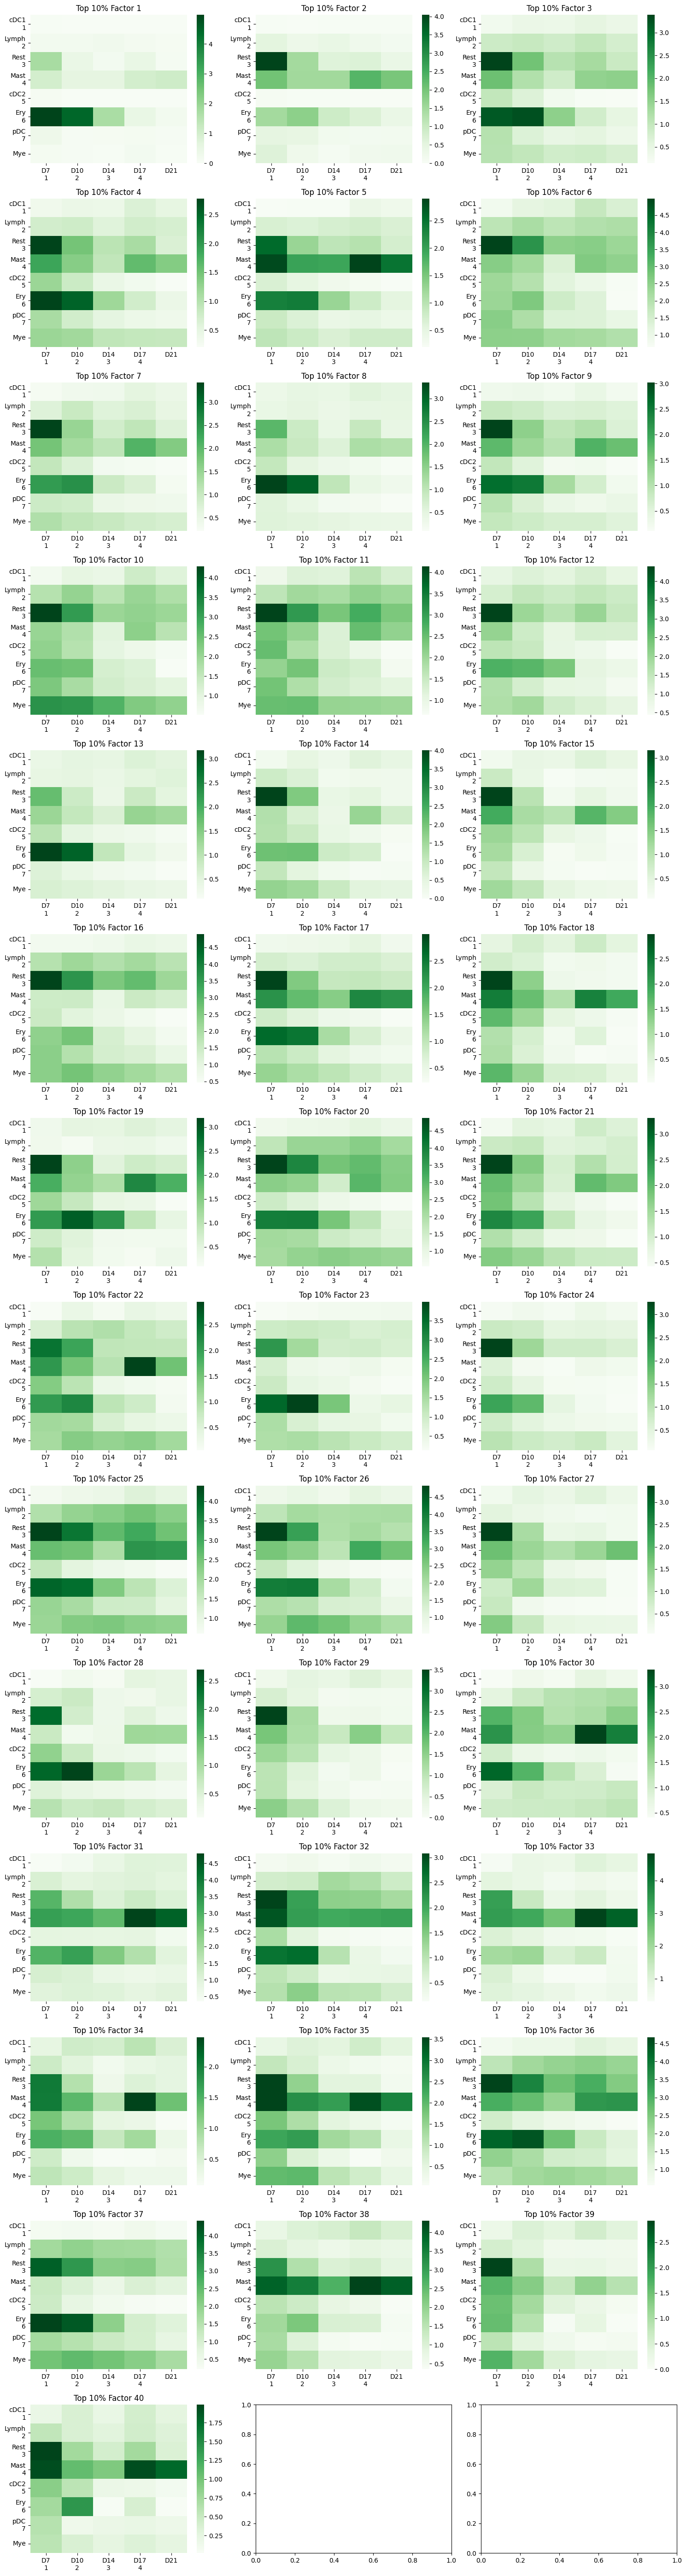

In [69]:
Z = ent.model.getExpectations()["Z"]["E"]

# make sure orientation is (cells, factors)
if Z.shape[0] != X_lineage.shape[0]:
    Z = Z.T

print(Z.shape)
print(X_lineage.shape)

n_factors = Z.shape[1]

fig, axes = plt.subplots(
    int(np.ceil(n_factors/3)),
    3,
    figsize=(15, 4*np.ceil(n_factors/3))
)

axes = np.ravel(axes)
for k in range(n_factors):

    threshold = np.percentile(Z[:, k], 70)

    mask = Z[:, k] >= threshold

    avg = X_lineage[mask].mean(axis=0)

    sns.heatmap(
        avg.T,
        ax=axes[k],
        cmap="Greens",
        xticklabels=timepoints,
        yticklabels=lineages
    )

    axes[k].set_title(f"Top 10% Factor {k+1}")


plt.tight_layout()

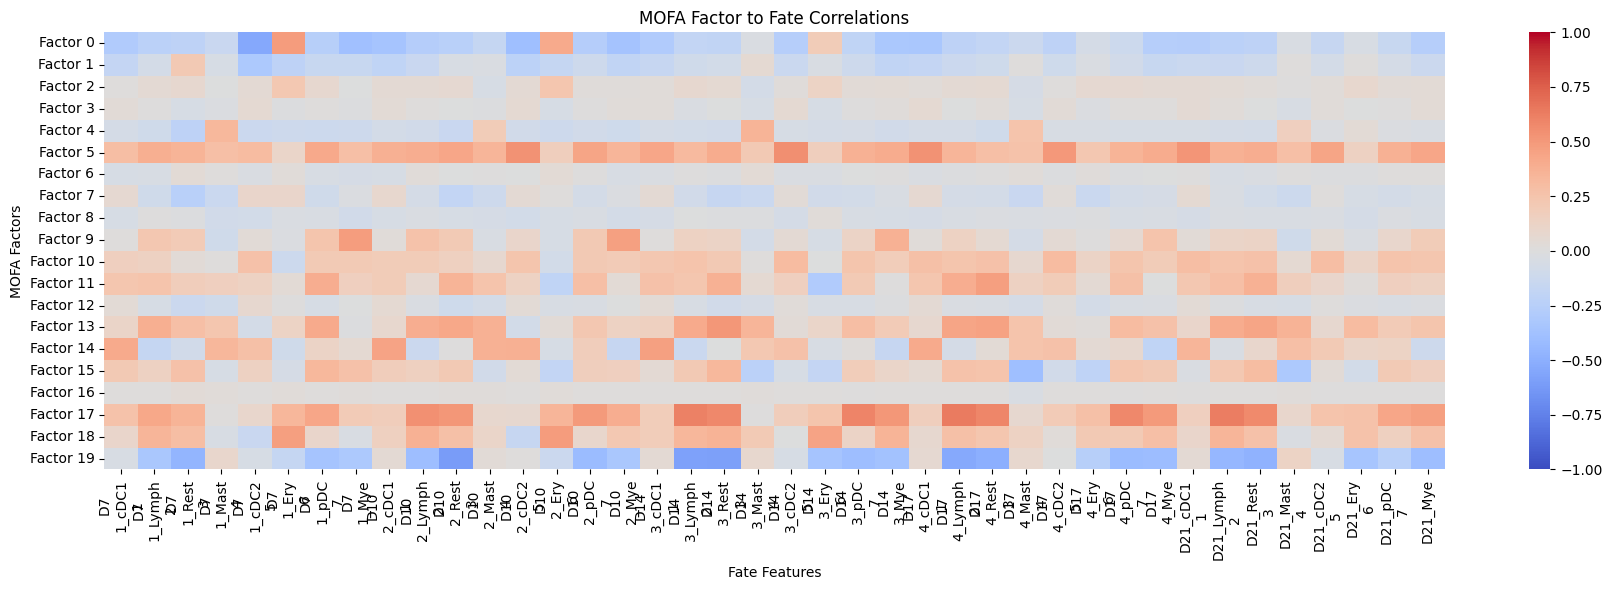

In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# Flatten lineage tensor
# ==========================================

# shape:
# (cells, timepoints * lineages)

X_fate_flat = x_bc_3d.reshape(
    x_bc_3d.shape[0],
    -1
)

# feature names
fate_features = [
    f"{t}_{l}"
    for t in timepoints
    for l in lineages
]

# ==========================================
# Compute correlations
# ==========================================

n_factors = Z.shape[1]

corr_mat = np.zeros(
    (n_factors, X_fate_flat.shape[1])
)

for k in range(n_factors):

    for j in range(X_fate_flat.shape[1]):

        corr_mat[k, j] = np.corrcoef(
            Z[:, k],
            X_fate_flat[:, j]
        )[0, 1]

# convert to dataframe
corr_df = pd.DataFrame(
    corr_mat,
    index=[f"Factor {i}" for i in range(n_factors)],
    columns=fate_features
)

# ==========================================
# Plot
# ==========================================

plt.figure(figsize=(18, 6))

sns.heatmap(
    corr_df,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("MOFA Factor to Fate Correlations")
plt.xlabel("Fate Features")
plt.ylabel("MOFA Factors")

plt.tight_layout()
plt.show()


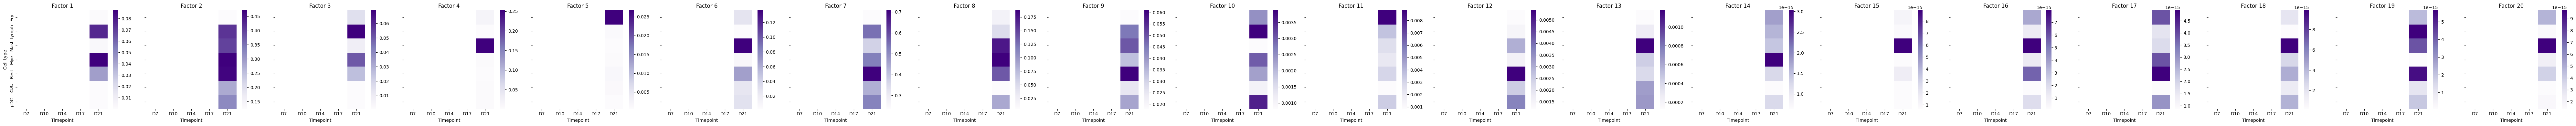

In [61]:
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import mofax as mfx

# in each bc of the factor, show heatmap of where all it has plotted as per 

TIMEPOINTS_ORDER = ["D7", "D10", "D14", "D17", "D21"]

def plot_factor_fate_from_loadings(model, fate_view_name="Fate_Tracking", normalise_rows=True, show_negative=False):
    # 1. Fetch weights matrix
    weights_dict = model.get_weights(views=fate_view_name)
    W = weights_dict[fate_view_name] if isinstance(weights_dict, dict) else weights_dict

    # 2. Extract features DataFrame safely
    features_df = model.get_features(views=fate_view_name)
    if isinstance(features_df, dict):
        features_df = features_df[fate_view_name]
    
    if isinstance(features_df, pd.DataFrame):
        feature_names = features_df["feature"].astype(str).tolist()
    else:
        feature_names = [str(f) for f in features_df]

    n_factors = W.shape[1]

    # 3. Parse names matching your pattern: e.g. D7\n1_cDC1\n1
    def parse_name(name):
        clean_name = name.replace("\n", "") 
        m = re.match(r"^([Dd]\d+)\d*_(.+)$", clean_name)
        if not m:
            raise ValueError(f"Feature name '{name}' (cleaned: '{clean_name}') layout unexpected.")
            
        tp = m.group(1).upper() 
        ct = re.sub(r"\d+$", "", m.group(2)) 
        return ct, tp

    celltypes = sorted({parse_name(f)[0] for f in feature_names})

    fig, axes = plt.subplots(1, n_factors, figsize=(4 * n_factors, 4), sharey=True)
    axes = np.atleast_1d(axes)

    for k in range(n_factors):
        mat = pd.DataFrame(np.nan, index=celltypes, columns=TIMEPOINTS_ORDER)
        for i, name in enumerate(feature_names):
            ct, tp = parse_name(name)
            if tp in TIMEPOINTS_ORDER:
                mat.loc[ct, tp] = W[i, k]

        # Handle direction of factors (MOFA factors can be positive or negative)
        if show_negative:
            # Look at absolute or negative trajectories if a factor uses negative weights
            mat_to_plot = mat.abs() 
            cmap_choice = "Purples"
        else:
            mat_to_plot = mat.where(mat > 0)
            cmap_choice = "Reds"

        # 4. CRITICAL FIX: Row-wise Min-Max Normalisation (0 to 1 scaling per cell type)
        if normalise_rows:
            # Shifts data so the lowest point of each cell type is 0, highest is 1
            row_min = mat_to_plot.min(axis=1)
            row_max = mat_to_plot.max(axis=1)
            mat_to_plot = mat_to_plot.sub(row_min, axis=0).div(row_max - row_min, axis=0)
            
            # Fill entirely empty rows with 0 to prevent visual artifacts
            mat_to_plot = mat_to_plot.fillna(0)
            vmin, vmax = 0, 1
        else:
            vmin, vmax = None, None

        sns.heatmap(
            mat_to_plot, 
            cmap=cmap_choice, 
            vmin=vmin, 
            vmax=vmax, 
            ax=axes[k],
            cbar=True, 
            mask=mat_to_plot.isna() if not normalise_rows else None,
        )
        
        axes[k].set_title(f"Factor {k + 1}")
        axes[k].set_xlabel("Timepoint")
        if k == 0:
            axes[k].set_ylabel("Cell type")

    plt.tight_layout()
    plt.show()

# Run script
model = mfx.mofa_model('/vast/projects/Sisseq/human-haematopoiesis-sis-seq/mofa_kj/20_factors_mofa.hdf5')

# normalise_rows=True scales 0-1 for each row so you see relative progression
plot_factor_fate_from_loadings(model, normalise_rows=False, show_negative=True)


ImportError: cannot import name 'plot_factor_fate_from_loadings' from 'mofax.plot_factors' (/vast/projects/Sisseq/human-haematopoiesis-sis-seq/mofa_kj/mofa_venv/lib64/python3.9/site-packages/mofax/plot_factors.py)